<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

# Python for Finance Course

**Module 3 &mdash; Portfolio**

[team@tpq.io](mailto:team@tpq.io) | [http://tpq.io](http://tpq.io)

The Python Quants GmbH

## Requirements

Make sure to have installed locally a **comprehensive Python installation** like the [Anaconda](http://repo.continuum.io) Python distribution.

Alternatively, and more easily, register on the **[Quant Platform](http://pqp.io)** where you can execute this Jupyter Notebook file in the browser. After registration, you find all Jupyter Notebook files of this course in the folder `pffcourse`.

## Necessary Imports

As usual, we need to **import certain modules/packages**.

In [1]:
import numpy as np  # array operations
import pandas as pd  # time series management
import matplotlib.pyplot as plt  # standard plotting library
from pylab import plt
plt.style.use('ggplot')
# put all plots in the notebook itself
%matplotlib inline

## Retrieving Stock Price Data

This module is about the **Markowitz Mean-Variance Portfolio Theoy (MVP)**. We need to retrieve some stock price data first to have something to work with. We build a portfolio of **tech companies**.

In [2]:
symbols = ['AAPL.O', 'MSFT.O', 'AMZN.O', 'INTC.O']  # our symbols
data = pd.read_csv('http://hilpisch.com/tr_eikon_eod_data.csv',
                   index_col=0, parse_dates=True)
data = data[symbols]

Let us inspect the **final five rows** of the `DataFrame` object.

In [3]:
data.tail()  # the final five rows

,AAPL.O,MSFT.O,AMZN.O,INTC.O
Date,,,,
2018-06-25,182.17,98.39,1663.15,50.71
2018-06-26,184.43,99.08,1691.09,49.67
2018-06-27,184.16,97.54,1660.51,48.76
2018-06-28,185.50,98.63,1701.45,49.25
2018-06-29,185.11,98.61,1699.80,49.71


A **graphical comparison** of the complete time series data might also be helpful. We **normalize** the starting values to 100.

/Users/yves/miniconda3/lib/python3.6/site-packages/ipykernel_launcher.py:1: DeprecationWarning: 
.ix is deprecated. Please use
.loc for label based indexing or
.iloc for positional indexing

See the documentation here:
http://pandas.pydata.org/pandas-docs/stable/indexing.html#ix-indexer-is-deprecated
  """Entry point for launching an IPython kernel.


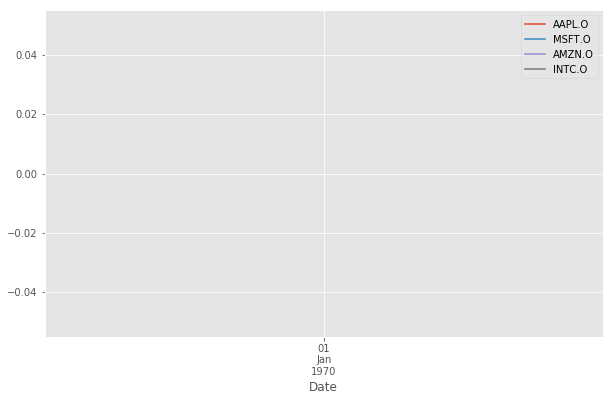

In [4]:
(data / data.ix[0] * 100).plot(figsize=(10, 6));

## Portfolio Returns

The first step in the calculation of a portfolio return is the calculation of the **annualized returns** of the different stocks based on the log returns for the respective time series.

In [5]:
# vectorized calculation of the log returns
log_rets = np.log(data / data.shift(1))

In [6]:
# annualized average log returns
rets = log_rets.mean() * 252
rets

AAPL.O    0.181303
MSFT.O    0.124840
AMZN.O    0.287547
INTC.O    0.096655
dtype: float64

We now need to represent a **portfolio** by (normalized) weightings for the single stocks. Let us start with an equal weighting scheme.

In [7]:
weights = np.array(len(symbols) * [1 / len(symbols)])  # equal weightings
weights

array([0.25, 0.25, 0.25, 0.25])

In mathematical terms, the portfolio return is given as

\begin{eqnarray*}
\mu_p &=& \mathbf{E} \left( \sum_I w_i r_i \right) \\
        &=& \sum_I w_i \mathbf{E}\left( r_i \right) \\
        &=& \sum_I w_i \mu_i \\
        &=& w^T \mu
\end{eqnarray*}

where the $w_i$ are the weights for the single portfolio components and the $r_i$ are the respective returns.

We get for our specific case the following result.

In [8]:
np.dot(weights, rets)  # portfolio return (equal weights)

0.17258602320245855

## Portfolio Variance

The calculation of the **portfolio variance** is a bit more involved. Let us start with the definition of the **covariance matrix** which is needed to this end.

\begin{eqnarray*}
\Sigma = \begin{bmatrix}
        \sigma_{1}^2 \ \sigma_{12} \ \dots \ \sigma_{1I} \\
        \sigma_{21} \ \sigma_{2}^2 \ \dots \ \sigma_{2I} \\
        \vdots \ \vdots \ \ddots \ \vdots \\
        \sigma_{I1} \ \sigma_{I2} \ \dots \ \sigma_{I}^2
    \end{bmatrix}
\end{eqnarray*}

Here, we have the variances of the single stocks on the diagonal and the covariances between two stocks in the other places.

In Python, this matrix is easily calculated.

In [9]:
log_rets.cov() * 252  # annualized covariance matrix

,AAPL.O,MSFT.O,AMZN.O,INTC.O
AAPL.O,0.064034,0.023656,0.027072,0.023635
MSFT.O,0.023656,0.051211,0.030382,0.030288
AMZN.O,0.027072,0.030382,0.095836,0.024999
INTC.O,0.023635,0.030288,0.024999,0.056395


Being equipped with the covariance matrix, the **portfolio variance** is defined as follows.

\begin{eqnarray*}
\sigma_p^2 &=& \mathbf{E}\left( (r - \mu)^2 \right) \\
        &=& \sum_{i \in I}\sum_{j \in I} w_i w_j \sigma_{ij} \\
        &=& w^T \Sigma w
\end{eqnarray*}

In Python, using NumPy, this is again a straightforward calculation.

In [10]:
# portfolio variance
pvar = np.dot(weights.T, np.dot(log_rets.cov() * 252, weights))
pvar

0.0367211840722477

The **portfolio volatility** then is

In [11]:
pvol = pvar ** 0.5
pvol

0.19162772260883262

## Random Portfolio Compositions

Next, let us generate a **random portfolio composition** and calculate the resulting portfolio return and variance.

In [12]:
weights = np.random.random(len(symbols))  # random numbers
weights /= np.sum(weights)  # normalization to 1

In [13]:
weights  # random portfolio composition

array([0.18108914, 0.46528506, 0.05650719, 0.2971186 ])

In [14]:
np.dot(weights, rets)  # portfolio return (random weights)

0.1358843927644674

In [15]:
# portfolio variance (random weights)
np.dot(weights.T, np.dot(log_rets.cov() * 252, weights))

0.03636624127326112

We are now going to implement a **Monte Carlo simulation** for the portfolio weights and collect the resulting portfolio returns and volatilities.

In [16]:
%%time
prets = []
pvols = []
for p in range(5000):
    weights = np.random.random(len(symbols))
    weights /= np.sum(weights)
    prets.append(np.sum(log_rets.mean() * weights) * 252)
    pvols.append(np.sqrt(np.dot(weights.T, 
                        np.dot(log_rets.cov() * 252, weights))))
prets = np.array(prets)
pvols = np.array(pvols)
portfolio = pd.DataFrame({'return': prets, 'volatility': pvols})

CPU times: user 5.18 s, sys: 15.5 ms, total: 5.2 s
Wall time: 5.2 s


The collected results allow for an **insightful visualization**. We can easily spot the area of the **minimum variance portfolio** and also see the **efficient frontier** quite well.

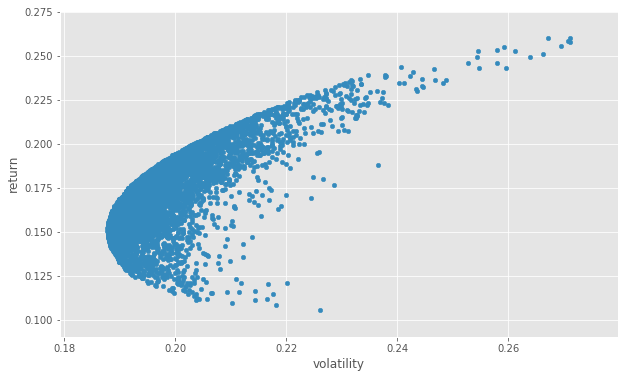

In [17]:
portfolio.plot(x='volatility', y='return', kind='scatter', figsize=(10, 6));

## Closing Remarks

This finishes the third module of the Python for Finance email course. In this module, you have learned:

* how to collect stock price data for multiple symbols
* how to calculate the return of a portfolio of multiple assets
* how to calculate the portfolio variance by the use of the covariance matrix
* how to simulate random portfolio compositions to visualize possible risk-return combinations

The portfolio theory presented in this module dates back to 1952 and is still a cornerstone today in (quantitative) finance.

## Exercises

In order to master the material of this module, do the following:

* replace the symbols used by other symbols and/or add more symbols
* work with different time horizons for the input data
* write Python code to find the minimum variance portfolio
* write Python code to find the portfolio compositions that make up the efficient frontier
* write Python code to determine the capital market line given a risk-free asset

## References

You find background information for the topics covered in this module in the following book:

* Hilpisch, Yves (2018): _Python for Finance_. 2nd ed., O'Reilly, ch. 13.

<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

<a href="http://tpq.io" target="_blank">http://tpq.io</a> | <a href="http://twitter.com/dyjh" target="_blank">@dyjh</a> | <a href="mailto:team@tpq.io">team@tpq.io</a>

**Quant Platform** |
<a href="http://quant-platform.com">http://quant-platform.com</a>

**Python for Finance** |
<a href="http://python-for-finance.com" target="_blank">Python for Finance @ O'Reilly</a>

**Derivatives Analytics with Python** |
<a href="http://derivatives-analytics-with-python.com" target="_blank">Derivatives Analytics @ Wiley Finance</a>

**Listed Volatility and Variance Derivatives** |
<a href="http://lvvd.tpq.io" target="_blank">Listed VV Derivatives @ Wiley Finance</a>